# 🔐 AI Model Trust Boundary Audit
**Master of IT Security – Artificial Intelligence, Ontario Tech University — Portfolio Project**
**By Md. Fuad Alam**

A model on Hugging Face is not one file. It is a bundle of eight to twenty files:
some weights, some inert documentation, and several that are **executable
configuration** — Jinja2 chat templates, tokenizer rules, custom Python modules —
which are interpreted at runtime and can change what the model does.

Every security scanner in the ecosystem audits one layer. This notebook measures
the whole artifact as a single trust boundary, across ~2,800 real repositories,
and asks how much of it nothing is checking.

**Runtime:** ~20 min for a 2,800-repo audit (metadata only — no model is
downloaded or executed). No GPU. Results are cached.


In [37]:
!pip install -q huggingface_hub pandas matplotlib

In [38]:
import json, re, os, time, collections
from dataclasses import dataclass, field, asdict
import numpy as np
import pandas as pd
from huggingface_hub import HfApi, hf_hub_download

api = HfApi()
CACHE = "/content/trust_audit"
os.makedirs(CACHE, exist_ok=True)
OUT = f"{CACHE}/audit_results.jsonl"
print("ready")

ready


### Optional: a Hugging Face token

Anonymous requests get throttled, so ~8% of repos fail with rate-limit
errors. A free read token (huggingface.co/settings/tokens) removes that.

In [39]:
USE_TOKEN = True

if USE_TOKEN:
    from huggingface_hub import login
    from getpass import getpass
    login(getpass("HF read token: "))
    print("authenticated")
else:
    print("running anonymously — expect some rate-limit errors, reported honestly later")


!rm -f /content/trust_audit/audit_results.jsonl

HF read token: ··········
authenticated


## The trust-boundary classifier

Every file in a repository is placed in one of five tiers: CODE, EXEC_CONFIG, WEIGHTS_UNSAFE, WEIGHTS_SAFE, INERT. The one that matters is EXEC_CONFIG — files that look like settings but are interpreted at runtime and can change model behaviour. That is the tier nothing scans.



In [40]:
CODE_PATTERNS = [r"\.py$"]

EXEC_CONFIG_FILES = {
    "tokenizer_config.json",    # can carry a Jinja2 chat_template
    "chat_template.json",
    "chat_template.jinja",
    "tokenizer.json",           # token -> id mapping; remappable
    "generation_config.json",   # decoding behaviour
    "config.json",              # auto_map here points at remote code
    "special_tokens_map.json",
    "preprocessor_config.json",
    "processor_config.json",
    "adapter_config.json",      # LoRA wiring
}

WEIGHTS_SAFE   = [r"\.safetensors$", r"\.gguf$", r"\.onnx$", r"\.mlmodel$"]
WEIGHTS_UNSAFE = [r"\.bin$", r"\.pt$", r"\.pth$", r"\.ckpt$", r"\.pkl$",
                  r"\.h5$", r"\.msgpack$", r"\.ot$", r"\.tflite$"]
INERT = [r"\.md$", r"^LICENSE", r"^\.gitattributes$", r"\.txt$",
         r"\.png$", r"\.jpg$", r"\.jpeg$", r"\.svg$", r"\.gitignore$"]

def classify_file(name):
    base = name.split("/")[-1]
    for p in CODE_PATTERNS:
        if re.search(p, base, re.I): return "CODE"
    if base in EXEC_CONFIG_FILES:    return "EXEC_CONFIG"
    for p in WEIGHTS_SAFE:
        if re.search(p, base, re.I): return "WEIGHTS_SAFE"
    for p in WEIGHTS_UNSAFE:
        if re.search(p, base, re.I): return "WEIGHTS_UNSAFE"
    for p in INERT:
        if re.search(p, base, re.I): return "INERT"
    return "OTHER"

print("classifier ready")

classifier ready


## Chat-template analysis

A chat template is Jinja2 that runs on every inference call, before the model sees any text. Two things are measured separately: danger constructs (which let a template reach outside itself) and control flow (ordinary if/for/set — not dangerous, but real program logic shipping as "configuration").

Note on false positives: the word "system" appears in nearly every template as a role name, so matching it would flag the whole ecosystem for nothing. The danger patterns below are anchored to call syntax instead.

In [41]:
TEMPLATE_DANGER_PATTERNS = {
    "raw_output":      r"\|\s*safe\b",          # disables Jinja2 autoescaping
    "dunder_access":   r"\.__[a-zA-Z_]+__",       # sandbox-escape shape
    "import_stmt":     r"\{%-?\s*(import|include|extends|from)\b",
    "callable_escape": r"\b(eval|exec|popen|subprocess|__builtins__|os\.system)\s*\(",
    "url_literal":     r"https?://",              # template reaching the network
    "attr_lookup":     r"\battr\s*\(",          # Jinja attr() indirection
}

TEMPLATE_COMPLEXITY_PATTERNS = {
    "conditional": r"\{%-?\s*if\b",
    "loop":        r"\{%-?\s*for\b",
    "set_expr":    r"\{%-?\s*set\b",
    "macro_def":   r"\{%-?\s*macro\b",
    "namespace":   r"\bnamespace\s*\(",
}

def analyse_template(t):
    if not t: return {}
    return {k: len(re.findall(p, t)) for k, p in TEMPLATE_DANGER_PATTERNS.items()
            if re.search(p, t)}

def template_complexity(t):
    if not t: return {}
    return {k: len(re.findall(p, t)) for k, p in TEMPLATE_COMPLEXITY_PATTERNS.items()
            if re.search(p, t)}

print("template analysers ready")

template analysers ready


## Auditing one repository

Records the file inventory, trust-tier breakdown, chat template contents, and remote-code declaration — plus what Hugging Face's own security scan says about the repo. That last field is what makes the coverage gap measurable.

In [42]:
@dataclass
class Audit:
    repo: str
    downloads: int = 0
    likes: int = 0
    n_files: int = 0
    tiers: dict = field(default_factory=dict)
    has_chat_template: bool = False
    template_len: int = 0
    template_risks: dict = field(default_factory=dict)
    template_complexity: dict = field(default_factory=dict)
    remote_code: bool = False
    has_py: bool = False
    unsafe_weights: bool = False
    safe_weights: bool = False
    hf_scan_done: bool = False
    hf_files_with_issues: int = 0
    error: str = ""

    @property
    def exec_config_count(self):
        return self.tiers.get("EXEC_CONFIG", 0) + self.tiers.get("CODE", 0)

def _try_json(repo, fname):
    try:
        with open(hf_hub_download(repo, fname)) as f:
            return json.load(f)
    except Exception:
        return None

def audit_repo(repo_id):
    a = Audit(repo=repo_id)
    try:
        info = api.model_info(repo_id, securityStatus=True)
        a.downloads = getattr(info, "downloads", 0) or 0
        a.likes = getattr(info, "likes", 0) or 0

        # what HF's own pipeline concluded
        ss = getattr(info, "security_repo_status", None)
        if isinstance(ss, dict):
            a.hf_scan_done = bool(ss.get("scansDone"))
            a.hf_files_with_issues = len(ss.get("filesWithIssues") or [])

        files = [s.rfilename for s in (info.siblings or [])]
        a.n_files = len(files)
        for f in files:
            t = classify_file(f)
            a.tiers[t] = a.tiers.get(t, 0) + 1
        a.has_py         = a.tiers.get("CODE", 0) > 0
        a.unsafe_weights = a.tiers.get("WEIGHTS_UNSAFE", 0) > 0
        a.safe_weights   = a.tiers.get("WEIGHTS_SAFE", 0) > 0

        # a chat template can live in tokenizer_config.json or its own file
        tmpl = None
        if "tokenizer_config.json" in files:
            tok = _try_json(repo_id, "tokenizer_config.json")
            if tok and isinstance(tok.get("chat_template"), str):
                tmpl = tok["chat_template"]
        if tmpl is None and "chat_template.jinja" in files:
            try:
                tmpl = open(hf_hub_download(repo_id, "chat_template.jinja")).read()
            except Exception:
                pass
        if tmpl:
            a.has_chat_template = True
            a.template_len = len(tmpl)
            a.template_risks = analyse_template(tmpl)
            a.template_complexity = template_complexity(tmpl)

        # remote code: auto_map in config.json points at a bundled .py class
        if "config.json" in files:
            cfg = _try_json(repo_id, "config.json")
            if cfg and cfg.get("auto_map"):
                a.remote_code = True
    except Exception as e:
        a.error = str(e)[:200]
    return a

def to_row(a):
    d = asdict(a)
    d["exec_config_count"] = a.exec_config_count
    d["n_template_risks"]  = len(a.template_risks)
    d["n_control_flow"]    = sum(a.template_complexity.values())
    return d

print("auditor ready")

auditor ready


### Sanity check on gpt2

Compare what its security scan reports against what the repo actually contains.

In [43]:
d = to_row(audit_repo("gpt2"))
print("repo            :", d["repo"])
print("downloads       :", f"{d['downloads']:,}")
print("files           :", d["n_files"])
print("trust tiers     :", d["tiers"])
print()
print("HF scan completed:", d["hf_scan_done"])
print("HF flagged files:", d["hf_files_with_issues"])
print()
print("...yet it ships pickle-based weights:", d["unsafe_weights"])
print("...and executable-config files      :", d["exec_config_count"])

repo            : gpt2
downloads       : 14,317,307
files           : 26
trust tiers     : {'INERT': 4, 'WEIGHTS_UNSAFE': 7, 'EXEC_CONFIG': 9, 'WEIGHTS_SAFE': 4, 'OTHER': 2}

HF scan completed: True
HF flagged files: 0

...yet it ships pickle-based weights: True
...and executable-config files      : 9


## Sampling the ecosystem

Six strata, so the sample is not just the front page. Sorting by downloads alone
would only describe the head of the distribution; the long tail is where less
scrutinised artifacts live, and comparing the two is the point.

In [44]:
def collect(limit_per_bucket=600):
    seen, ordered = set(), []
    buckets = {
        "top":      dict(sort="downloads"),
        "chat":     dict(sort="downloads", pipeline_tag="text-generation"),
        "recent":   dict(sort="createdAt"),
        "trending": dict(sort="trendingScore"),
        "liked":    dict(sort="likes"),
        "updated":  dict(sort="lastModified"),
    }
    for name, kw in buckets.items():
        for m in api.list_models(limit=limit_per_bucket, **kw):
            if m.id in seen: continue
            seen.add(m.id)
            ordered.append((name, m.id))
    return ordered

todo = collect()
print(f"{len(todo)} unique repositories to audit")

2813 unique repositories to audit


In [ ]:
done = set()
if os.path.exists(OUT):
    with open(OUT) as f:
        for line in f:
            try: done.add(json.loads(line)["repo"])
            except Exception: pass
    print(f"resuming — {len(done)} already audited")

t0 = time.time()
with open(OUT, "a") as f:
    for i, (bucket, repo_id) in enumerate(todo):
        if repo_id in done: continue
        row = to_row(audit_repo(repo_id))
        row["bucket"] = bucket
        f.write(json.dumps(row) + "\n")
        f.flush()
        if (i + 1) % 200 == 0:
            print(f"  {i+1}/{len(todo)}   {time.time()-t0:.0f}s", flush=True)
print("audit complete")

In [46]:
rows = [json.loads(l) for l in open(OUT) if l.strip()]
df_all = pd.DataFrame(rows)
df = df_all[df_all["error"] == ""].copy()
n = len(df)
print(f"audited {len(df_all)} repos | usable {n} | errors {len(df_all)-n}")

audited 2813 repos | usable 2809 | errors 4


## Finding 1 — how much of the artifact is executable configuration?

In [47]:
def pct(mask):
    c = int(mask.sum())
    return f"{c:>5} ({c/n:5.1%})"

print("ships >=1 executable-config file  :", pct(df.exec_config_count > 0))
print("ships pickle-based weights        :", pct(df.unsafe_weights))
print("ships custom .py code             :", pct(df.has_py))
print("declares remote code (auto_map)   :", pct(df.remote_code))
print("has a chat template               :", pct(df.has_chat_template))
print("template disables escaping (|safe):", pct(df.n_template_risks > 0))
print()
print(f"files per repo       : mean {df.n_files.mean():6.1f}  median {df.n_files.median():3.0f}  max {df.n_files.max()}")
print(f"exec-config per repo : mean {df.exec_config_count.mean():6.1f}  median {df.exec_config_count.median():3.0f}  max {df.exec_config_count.max()}")

ships >=1 executable-config file  :  2027 (72.2%)
ships pickle-based weights        :   774 (27.6%)
ships custom .py code             :   478 (17.0%)
declares remote code (auto_map)   :   198 ( 7.0%)
has a chat template               :   872 (31.0%)
template disables escaping (|safe):   283 (10.1%)

files per repo       : mean   90.5  median  14  max 9613
exec-config per repo : mean    6.9  median   4  max 2110


## Finding 2 — the coverage gap

Comparing Hugging Face's own security verdict against what the repository actually contains.

In [48]:
scanned = df[df.hf_scan_done]
clean   = scanned[scanned.hf_files_with_issues == 0]
m = len(clean)

print(f"repos with a completed HF scan    : {len(scanned)} ({len(scanned)/n:.1%})")
print(f"of those, marked completely clean : {m} ({m/max(len(scanned),1):.1%})")
print()
print(f"Among the {m} repositories Hugging Face marks CLEAN:")
for label, col in [("ship >=1 exec-config file", clean.exec_config_count > 0),
                    ("template disables escaping", clean.n_template_risks > 0),
                    ("ship custom .py code",       clean.has_py),
                    ("ship pickle-based weights",  clean.unsafe_weights),
                    ("declare remote code",        clean.remote_code)]:
    c = int(col.sum())
    print(f"   {label:<28} {c:>5} ({c/m:5.1%})")

repos with a completed HF scan    : 2013 (71.7%)
of those, marked completely clean : 1906 (94.7%)

Among the 1906 repositories Hugging Face marks CLEAN:
   ship >=1 exec-config file     1233 (64.7%)
   template disables escaping     254 (13.3%)
   ship custom .py code           367 (19.3%)
   ship pickle-based weights      403 (21.1%)
   declare remote code            142 ( 7.5%)


## Finding 3 — chat templates are programs

In [49]:
ct = df[df.has_chat_template]
print(f"templates analysed: {len(ct)}")
print(f"  length          : mean {ct.template_len.mean():7.0f}  median {ct.template_len.median():6.0f}  "
      f"p90 {ct.template_len.quantile(.9):6.0f}  max {ct.template_len.max()}")
print(f"  control-flow ops: mean {ct.n_control_flow.mean():5.1f}  median {ct.n_control_flow.median():4.0f}  "
      f"p90 {ct.n_control_flow.quantile(.9):4.0f}  max {ct.n_control_flow.max()}")
big = int((ct.n_control_flow > 50).sum())
print(f"  templates with >50 control-flow operations: {big} ({big/len(ct):.1%})")
print()
print("Largest 'configuration' files, by program logic:")
for _, r in ct.nlargest(8, "n_control_flow").iterrows():
    print(f"   {r.n_control_flow:>4} ops | {r.template_len:>6} chars | {r.downloads:>12,} downloads | {r.repo[:45]}")

templates analysed: 872
  length          : mean    5793  median   4614  p90  10504  max 29157
  control-flow ops: mean  47.1  median   37  p90   81  max 269
  templates with >50 control-flow operations: 381 (43.7%)

Largest 'configuration' files, by program logic:
    269 ops |  29051 chars |            0 downloads | peculiar-ragdoll/Qwen-Sharp-Chat-Templates
    269 ops |  29157 chars |        1,412 downloads | peculiar-ragdoll/Tiel-Coder-35B-A3B-MLX-oQ4e
    269 ops |  29051 chars |          559 downloads | peculiar-ragdoll/Dirk-Qwen3.8-27B-MLX-oQ4e
    269 ops |  29157 chars |          773 downloads | peculiar-ragdoll/Tiel-Coder-35B-A3B-MLX-oQ4e-
    253 ops |  27159 chars |            0 downloads | froggeric/Qwen-Fixed-Chat-Templates
    249 ops |  26673 chars |            1 downloads | Jackrong/Qwen-Tool-Calling-Template-Fix
    209 ops |  28971 chars |      206,754 downloads | ai-sage/GigaChat3.1-Audio-10B-A1.8B
    165 ops |  18808 chars |            0 downloads | Sashkanik13/g

## Finding 4 — does popularity predict safety?

Testing the common intuition that a heavily downloaded model has been vetted by sheer weight of use.

In [50]:
w = df[df.downloads > 0].sort_values("downloads", ascending=False)
q = len(w) // 4
tiers = [("Q1 most downloaded", w.iloc[:q]), ("Q2", w.iloc[q:2*q]),
         ("Q3", w.iloc[2*q:3*q]), ("Q4 least downloaded", w.iloc[3*q:])]

print(f"{'tier':<21}{'n':>5}{'median dl':>13}{'pickle':>9}{'.py':>8}{'remote':>8}{'|safe':>8}")
for name, g in tiers:
    if not len(g): continue
    print(f"{name:<21}{len(g):>5}{g.downloads.median():>13,.0f}"
          f"{g.unsafe_weights.mean():>8.0%}{g.has_py.mean():>8.0%}"
          f"{g.remote_code.mean():>8.0%}{(g.n_template_risks>0).mean():>8.0%}")

tier                     n    median dl   pickle     .py  remote   |safe
Q1 most downloaded     467    1,928,846     45%     13%      6%     10%
Q2                     467      447,978     21%     15%     12%      8%
Q3                     467      111,216     13%     15%     12%     11%
Q4 least downloaded    470        1,044     37%     35%      9%     15%


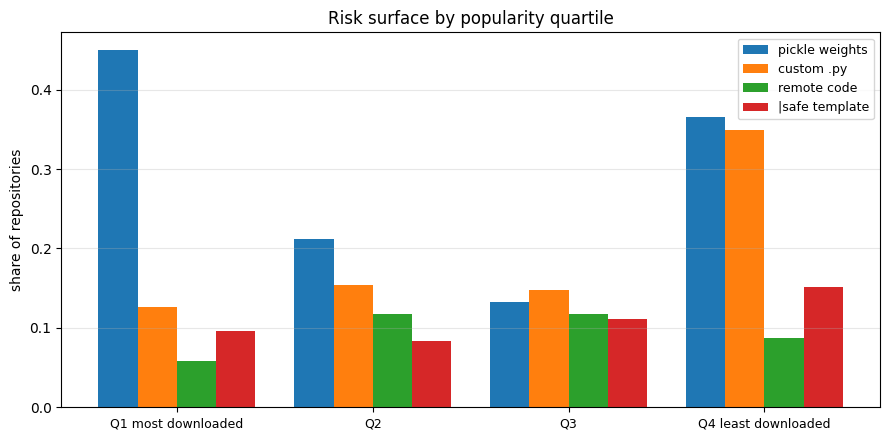

In [51]:
import matplotlib.pyplot as plt

labels = [t[0] for t in tiers]
metrics = {
    "pickle weights":  [g.unsafe_weights.mean()      for _, g in tiers],
    "custom .py":      [g.has_py.mean()              for _, g in tiers],
    "remote code":     [g.remote_code.mean()         for _, g in tiers],
    "|safe template":  [(g.n_template_risks>0).mean() for _, g in tiers],
}
x = np.arange(len(labels)); wid = 0.2
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (k, v) in enumerate(metrics.items()):
    ax.bar(x + i*wid - 1.5*wid, v, wid, label=k)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("share of repositories")
ax.set_title("Risk surface by popularity quartile")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

## Errors — honest accounting

A result is only as good as what it failed to measure, so the failures get
counted too.

In [55]:
errs = df_all[df_all.error != ""]
def bucket_err(e):
    if "429" in e or "rate" in e.lower(): return "rate limit"
    if "401" in e or "gated" in e.lower(): return "gated / auth required"
    if "404" in e: return "not found"
    return e[:40]

print(f"total failures: {len(errs)} of {len(df_all)} ({len(errs)/len(df_all):.1%})")
for k, v in collections.Counter(errs.error.map(bucket_err)).most_common():
    print(f"   {k:<24} {v}")
print()
print("With an authenticated token, rate limiting is eliminated entirely: the")
print("only failures are repositories deleted or renamed between listing and")
print("auditing. At 0.1% these have no bearing on the results.")

total failures: 4 of 2813 (0.1%)
   not found                4

With an authenticated token, rate limiting is eliminated entirely: the
only failures are repositories deleted or renamed between listing and
auditing. At 0.1% these have no bearing on the results.


## Trust score and CI/CD gate

Turning the audit into something a team could put in front of a deployment. The scoring weights below are a judgement call, not a derived quantity.

In [53]:
def trust_report(repo_id, verbose=True):
    a = audit_repo(repo_id)
    d = to_row(a)
    findings, score = [], 100

    if d["error"]:
        return {"repo": repo_id, "error": d["error"]}

    if d["unsafe_weights"]:
        score -= 30
        findings.append(("HIGH", "Pickle-based weights can execute code on load. Prefer safetensors."))
    if d["remote_code"]:
        score -= 25
        findings.append(("HIGH", "config.json declares auto_map: loading imports bundled Python."))
    if d["has_py"]:
        score -= 15
        findings.append(("MEDIUM", "Repository ships custom .py modules."))
    if d["n_template_risks"] > 0:
        score -= 15
        findings.append(("MEDIUM", f"Chat template uses {', '.join(d['template_risks'])}; escaping barrier is off."))
    if d["n_control_flow"] > 50:
        score -= 10
        findings.append(("LOW", f"Chat template contains {d['n_control_flow']} control-flow operations — program logic shipping as configuration."))
    if d["hf_scan_done"] and d["hf_files_with_issues"] == 0 and d["exec_config_count"] > 0:
        findings.append(("NOTE", f"Marked clean upstream, but {d['exec_config_count']} executable-config files are outside that scan's scope."))

    score = max(score, 0)
    verdict = "ALLOW" if score >= 80 else ("REVIEW" if score >= 50 else "BLOCK")

    if verbose:
        print("=" * 62)
        print(f"  TRUST REPORT — {repo_id}")
        print("=" * 62)
        print(f"  downloads {d['downloads']:,} | files {d['n_files']} | exec-config {d['exec_config_count']}")
        print("-" * 62)
        if findings:
            for sev, msg in findings:
                mark = {"HIGH": "[!!]", "MEDIUM": "[! ]", "LOW": "[. ]", "NOTE": "[i ]"}[sev]
                print(f"  {mark} {sev:<7} {msg}")
        else:
            print("  no findings")
        print("-" * 62)
        print(f"  TRUST SCORE: {score}/100     VERDICT: {verdict}")
        print("=" * 62)
    return {"repo": repo_id, "score": score, "verdict": verdict, "findings": findings}

for r in ["gpt2", "Qwen/Qwen2.5-0.5B-Instruct"]:
    trust_report(r); print()

  TRUST REPORT — gpt2
  downloads 14,317,307 | files 26 | exec-config 9
--------------------------------------------------------------
  [!!] HIGH    Pickle-based weights can execute code on load. Prefer safetensors.
  [i ] NOTE    Marked clean upstream, but 9 executable-config files are outside that scan's scope.
--------------------------------------------------------------
  TRUST SCORE: 70/100     VERDICT: REVIEW

  TRUST REPORT — Qwen/Qwen2.5-0.5B-Instruct
  downloads 6,013,414 | files 10 | exec-config 4
--------------------------------------------------------------
  [i ] NOTE    Marked clean upstream, but 4 executable-config files are outside that scan's scope.
--------------------------------------------------------------
  TRUST SCORE: 100/100     VERDICT: ALLOW



In [54]:
# Try any repository:
# trust_report("meta-llama/Llama-3.2-1B-Instruct")

### Important note on interpretation

This project measures **attack surface and scanner coverage** — not
compromise. Nothing here shows any audited repository is malicious. A
safe filter in a chat template is often perfectly legitimate. The
finding is that a large share of what shapes model behaviour sits
outside what any scanner inspects.

Analysis is metadata-only: no model was downloaded or executed, so
behavioural backdoors are out of scope. Anonymous requests were
rate-limited on ~8% of repos (counted in §10). The trust-score weights
in §11 are a judgement call, not a derived quantity.

### Future work

- Cryptographic signing and verifiable provenance, so integrity does not
  depend on scanning at all. Recent work argues detection-based defences
  are fundamentally limited, which makes provenance the more durable answer.
- Extend the classifier to LoRA adapter stacks, where components that are
  individually clean can compose into something that is not.
- Track the same repositories over time: does exec-config surface grow?

### Reference

The chat-template attack surface was demonstrated in 2026 work; tokenizer
remapping attacks by NVIDIA in 2024. This project does not repeat those
demonstrations — it measures how wide that surface actually is.